# COGS 108 - EDA Checkpoint

## Authors

Khushi: Conceptualization, Background research, Writing – original draft  
Valmik: Data curation, Methodology, Analysis  
Aanya: Visualization, Writing – review & editing  
Alexa: Project administration, Software  
Hussain: Data Cleaning, Data Plotting, Writing - review & editing

# Research Question

This project investigates whether court surface type is associated with or improves the confidence in prediction of match outcomes in professional tennis matches.
We will examine this relationship using key variables including match outcome, player ranking difference, and court surface (hard, clay, grass).
This research question is answerable using observational match-level data and statistical analysis.
Understanding this relationship is important because it helps determine whether playing conditions meaningfully affect match predictability, which can improve performance analysis, forecasting models, and strategic decision-making in professional tennis.


## Background and Prior Work

Tennis is one of the world's most popular and competitive sports, with professional matches played across diverse environmental conditions that can significantly influence player performance and match outcomes. Among these conditions, court surface type—primarily hard courts, clay courts, and grass courts—has long been recognized as a fundamental factor that shapes playing styles, strategic approaches, and competitive advantages. Understanding how court surface affects match outcomes is not only important for players, coaches, and analysts seeking to optimize performance and develop effective strategies, but also for improving the accuracy of predictive models used in sports analytics, broadcasting, and tournament planning. As professional tennis continues to generate vast amounts of data and increasingly relies on statistical modeling for decision-making, investigating whether court surface type meaningfully contributes to match outcome prediction represents a critical area of research with practical applications across multiple stakeholders in the sport.


Prior research has established that court surface type significantly influences match outcomes and prediction accuracy in professional tennis.<a name="cite_ref-1"></a><sup>1</sup> McHale and Morton (2011) demonstrated that models incorporating surface information alongside match scores and play data achieved higher forecasting accuracy than ranking-based models alone, though they did not account for dependencies between factors.<a name="cite_ref-2"></a><sup>2</sup> More recent studies have developed surface-specific player ratings using network analysis and machine learning approaches, with models trained on over 83,000 matches showing that surface-specific features improve prediction accuracy beyond classical approaches.<a name="cite_ref-3"></a><sup>3</sup> The physical mechanisms underlying these effects are well-documented: grass courts produce fast, low bounces that favor aggressive serve-and-volley play and shorter rallies; clay courts generate slower, higher bounces that extend rally length and favor baseline players with strong defensive skills; and hard courts provide medium-speed conditions with predictable bounces that accommodate diverse playing styles.<a name="cite_ref-4"></a><sup>4</sup> Research using dynamic models has shown that elite players like Rafael Nadal and Roger Federer exhibit measurably different strength levels across surface types, with prediction models achieving approximately 70% accuracy when incorporating surface-specific player abilities.<a name="cite_ref-5"></a><sup>5</sup> However, recent work has found that model performance varies considerably by surface, with prediction accuracy notably lower on grass courts compared to hard and clay courts, suggesting that surface-specific characteristics create unique challenges for match outcome modeling.<a name="cite_ref-6"></a><sup>6</sup>




Despite the extensive body of research on tennis match prediction, several important limitations and gaps remain. First, many existing studies focus primarily on elite players or Grand Slam tournaments, potentially limiting the generalizability of findings to the broader professional tennis ecosystem that includes lower-tier tournaments and emerging players. Second, while surface-specific models have been developed, there is inconsistency in how researchers operationalize and measure surface effects—some studies treat surface as a categorical variable while others develop continuous surface-specific rating systems, making cross-study comparisons difficult. Third, most prediction models achieve moderate accuracy levels (typically 65-75%), suggesting that important predictive factors may be missing or that the inherent variability in tennis matches limits deterministic prediction. Fourth, there is limited research examining whether the predictive value of court surface has changed over time as equipment technology, training methods, and player athleticism have evolved, potentially reducing historical surface-specific advantages. Finally, few studies have systematically compared the relative importance of court surface against other environmental and contextual factors such as tournament prestige, match format, and player fatigue across large, diverse datasets.




Our project addresses these gaps by conducting a comprehensive analysis of whether court surface type improves match outcome prediction across a large, diverse dataset of professional tennis matches from both ATP and WTA tours. Unlike previous studies that often focus on specific tournaments or player subsets, we will examine matches across multiple tournament levels and time periods to assess the robustness and generalizability of surface effects. By systematically comparing prediction models with and without surface information while controlling for player ranking differences, we can directly quantify the added predictive value that surface type provides beyond baseline player quality measures. This approach will help determine whether the widely-assumed importance of court surface in tennis translates into meaningful improvements in statistical prediction, or whether other factors dominate match outcomes. Furthermore, by analyzing both men's and women's professional tennis, we can explore whether surface effects operate similarly across different competitive contexts. The findings from this research will have practical value for sports analysts developing forecasting models, players and coaches making strategic decisions about tournament selection and preparation, and researchers seeking to understand the relative importance of environmental factors in athletic performance prediction.






Works Cited


<a name="cite_note-1"></a>[^](#cite_ref-1) Buhamra, N., Groll, A., & Brunner, S. (2024). Modeling and prediction of tennis matches at Grand Slam tournaments. Journal of Sports Analytics.


<a name="cite_note-2"></a>[^](#cite_ref-2) McHale, I., & Morton, A. (2011). A Bradley-Terry type model for forecasting tennis match outcomes. International Journal of Forecasting.


<a name="cite_note-3"></a>[^](#cite_ref-3) Bayram, F., Garbarino, D., & Barla, A. (2021). Predicting tennis match outcomes with network analysis and machine learning. In SOFSEM 2021: Theory and Practice of Computer Science (pp. 526-541). Springer.


<a name="cite_note-4"></a>[^](#cite_ref-4) Barnett, T., & Pollard, G. (2007). How the tennis court surface affects player performance and injuries. Medicine & Science in Sports & Exercise.


<a name="cite_note-5"></a>[^](#cite_ref-5) Kovalchik, S., Ingram, M., & Gorgi, P. (2019). Analysis and forecasting of tennis matches by using a high dimensional dynamic model. Journal of the Royal Statistical Society: Series A, 182(4), 1393-1425.


<a name="cite_note-6"></a>[^](#cite_ref-6) Liu, J., et al. (2024). Momentum prediction models of tennis match based on CatBoost regression and random forest algorithms. Scientific Reports, 14, Article 18552.


# Hypothesis

We hypothesize that court surface type will be positively associated with the accuracy of predicting match outcomes in professional tennis matches.
This expectation is based on prior research suggesting that different surfaces systematically affect ball speed, rally length, and serve effectiveness, which in turn influence player performance and match results.


## Data


### Data overview

This subsection summarizes the processed data we use for EDA and why it is relevant to our research question. We use the fully wrangled match-level dataset produced in the Data Checkpoint. It is loaded from `data/02-processed/tennis_matches_processed_fullcols.csv`. The processed data has 223,739 matches and 51 variables. Rows with missing surface, winner_rank, or loser_rank were dropped. Key variables for EDA and later modeling include: **surface** (court type: hard, clay, grass, carpet, etc.), **winner_rank** and **loser_rank** (ATP/WTA rankings at match time), **rank_diff** (winner_rank − loser_rank), **league** (atp/wta), **tourney_date**, and **tourney_level**. This dataset is directly relevant to our research question because it contains match outcomes, rankings, and court surface, allowing us to explore whether surface is associated with predictability of outcomes (e.g., how often the higher-ranked player wins) and to build models with and without surface.


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm
"""
import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]
get_data.get_raw(datafiles,destination_directory='data/00-raw/')
""";
# This cell is unnecessary since our data was uploaded to the directory independently.

### Dataset #1: Processed ATP/WTA match data


**Source:** Built from Kaggle ATP/WTA Tennis Matches (Taylor Brownlow); wrangling and variable definitions are in `01-DataCheckpoint.ipynb`.  
**File:** `data/02-processed/tennis_matches_processed_fullcols.csv`  
**Observations:** 223,739 matches (after dropping rows missing surface, winner_rank, or loser_rank).  
**Variables:** 51 columns, including surface, winner_rank, loser_rank, rank_diff, league, tourney_date, tourney_level, and match identifiers. Each row is one completed match. Surface is standardized to lowercase (e.g., hard, clay, grass, carpet). rank_diff = winner_rank − loser_rank (negative values indicate the lower-ranked player won).

This project uses a match-level dataset of professional tennis matches (ATP and WTA). Each row represents one completed match, and columns describe the match context (date, tournament, round, surface), the two players, and outcome-related information (winner/loser). This dataset is directly relevant because it includes the two predictors we care about—court surface type and player rankings—as well as the match outcome (winner vs. loser), letting us test whether surface adds predictive value beyond ranking differences.
The most important variables for our research question are: surface (categorical: hard/clay/grass; the playing condition we want to test), winner_rank and loser_rank (numeric rankings at the time of the match; lower numbers indicate better players, e.g., rank 1 is best), and the match outcome (captured by the winner/loser fields). Rankings do not have physical “units,” but they are an ordered scale where smaller values indicate stronger players. From these columns, we will compute rank_diff = winner_rank - loser_rank, which represents the ranking gap between the two competitors for each match. We will also create a binary outcome variable such as higher_rank_won, indicating whether the higher-ranked player (smaller rank number) won the match.
Major concerns / limitations: this dataset is observational (we can evaluate predictive relationships, not causality). Rankings can be missing for some matches, especially in older records or lower-profile tournaments, and surface labels may include less common categories (e.g., carpet) or inconsistent capitalization. Rankings also do not capture short-term factors like injuries, fatigue, or recent form. Despite these limitations, the dataset is large and contains the key variables needed to answer our research question and compare prediction performance with vs. without surface type.


In [3]:
# Quick load check: load processed data (no need to re-run raw wrangling)
import pandas as pd
df = pd.read_csv("data/02-processed/tennis_matches_processed_fullcols.csv")
print("Shape:", df.shape)
print("Key columns:", [c for c in ["surface", "winner_rank", "loser_rank", "rank_diff", "league"] if c in df.columns])
df.head(2)

/tmp/ipykernel_2490249/1034932600.py:3: DtypeWarning: Columns (8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/02-processed/tennis_matches_processed_fullcols.csv")


Shape: (223739, 51)
Key columns: ['surface', 'winner_rank', 'loser_rank', 'rank_diff', 'league']


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,league,rank_diff
0,2019-M020,Brisbane,hard,32.0,A,2018-12-31,300,105453,2.0,NaN,...,20.0,14.0,10.0,15.0,9.0,3590.0,16.0,1977.0,atp,-7.0
1,2019-M020,Brisbane,hard,32.0,A,2018-12-31,299,106421,4.0,NaN,...,7.0,10.0,10.0,13.0,16.0,1977.0,239.0,200.0,atp,-223.0


### Dataset #2

Since we we use one main dataset for EDA (the processed ATP/WTA matches in Dataset #1). A second Kaggle source was considered in the proposal for validation; the current EDA and modeling use only the processed match file from Dataset #1 as we have deemed it sufficient for our usecase.

## Results


### Exploratory Data Analysis

We load the fully wrangled data from `data/02-processed/tennis_matches_processed_fullcols.csv` and explore distributions of key variables (surface, ranking difference, league, time) and the relationship between court surface and match outcome predictability (e.g., how often the higher-ranked player wins by surface). This EDA informs whether surface is a relevant factor for our prediction models and how to interpret results. All code below uses the processed dataset loaded in the Data section. 



#### Section 1: Distribution of key variables

This subsection summarizes how the data are distributed across the main variables we use for modeling. We examine the distribution of court surface, ranking difference (rank_diff), league (ATP vs WTA), and match year. This shows whether the data are balanced across surfaces and time, and whether rank_diff is skewed (e.g., many upsets would yield a long left tail). Understanding these distributions is important for later modeling (e.g., stratification or weighting) and for interpreting summary statistics (e.g., we use medians for skewed variables where appropriate).

/tmp/ipykernel_2490249/1048031337.py:4: DtypeWarning: Columns (8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/02-processed/tennis_matches_processed_fullcols.csv")


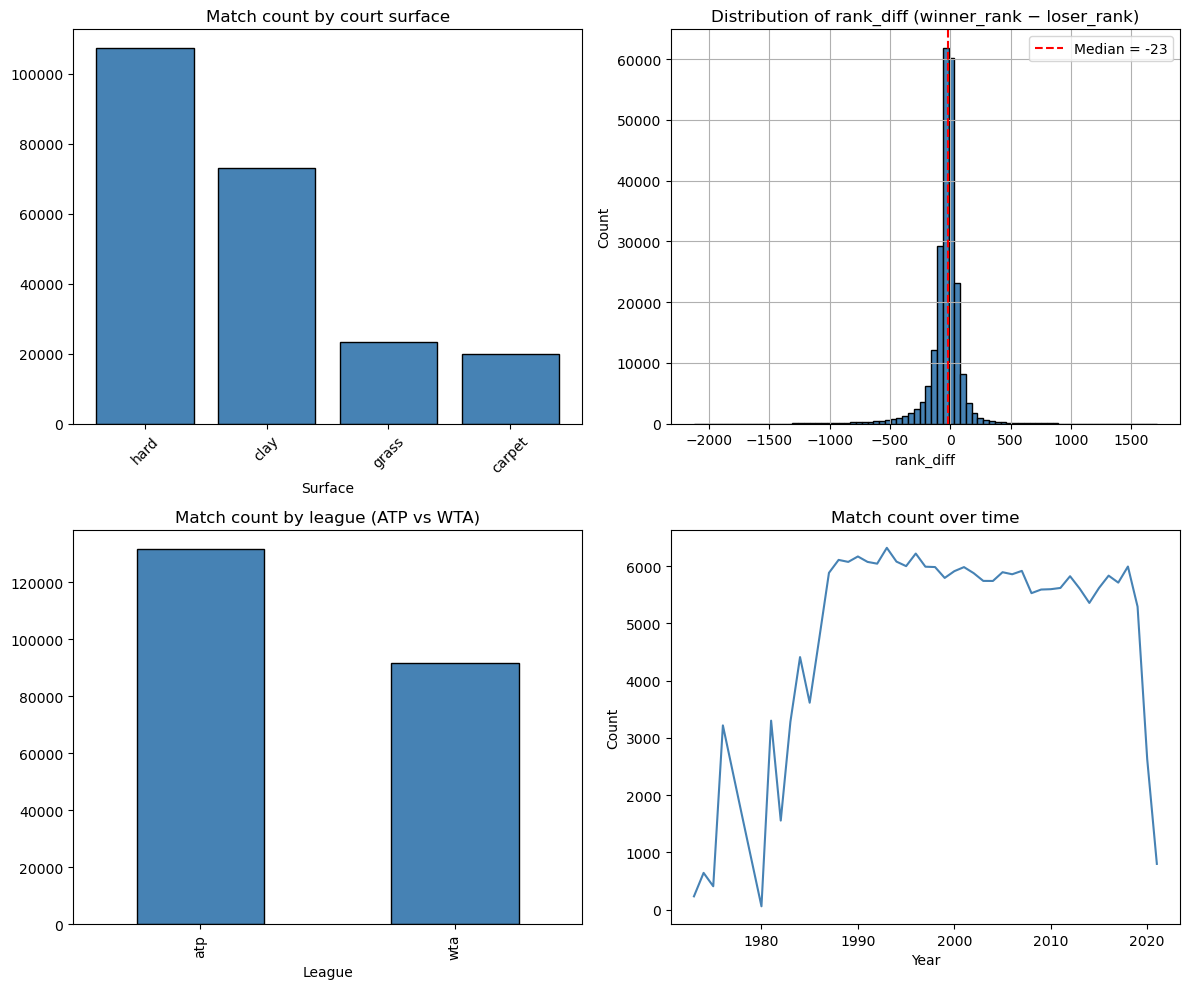

Summary: rank_diff median = -23.0 , mean = -39.23
Surface value_counts:
 surface
hard      107342
clay       73038
grass      23481
carpet     19878
Name: count, dtype: int64


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/02-processed/tennis_matches_processed_fullcols.csv")
df["tourney_date"] = pd.to_datetime(df["tourney_date"], errors="coerce")
df["year"] = df["tourney_date"].dt.year

# Surface distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

surf_counts = df["surface"].value_counts()
axes[0, 0].bar(surf_counts.index.astype(str), surf_counts.values, color="steelblue", edgecolor="black")
axes[0, 0].set_title("Match count by court surface")
axes[0, 0].set_xlabel("Surface")
axes[0, 0].tick_params(axis="x", rotation=45)

# Rank difference distribution (median is more appropriate than mean for skewed data)
df["rank_diff"].hist(bins=80, ax=axes[0, 1], color="steelblue", edgecolor="black")
axes[0, 1].axvline(df["rank_diff"].median(), color="red", linestyle="--", label=f"Median = {df['rank_diff'].median():.0f}")
axes[0, 1].set_title("Distribution of rank_diff (winner_rank − loser_rank)")
axes[0, 1].set_xlabel("rank_diff")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# League
df["league"].value_counts().plot(kind="bar", ax=axes[1, 0], color="steelblue", edgecolor="black")
axes[1, 0].set_title("Match count by league (ATP vs WTA)")
axes[1, 0].set_xlabel("League")

# Matches per year
df.groupby("year").size().plot(ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("Match count over time")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Summary: rank_diff median =", df["rank_diff"].median(), ", mean =", round(df["rank_diff"].mean(), 2))
print("Surface value_counts:\n", df["surface"].value_counts())

Hard and clay have the most matches; grass and carpet have fewer. Rank difference is right-skewed (many matches where the winner was higher-ranked than the loser, i.e., positive rank_diff). Reporting the median alongside the mean is appropriate for rank_diff. Match volume grows over time and is roughly split between ATP and WTA.

#### Section 2: Surface and match outcome predictability

This subsection examines whether outcome predictability (how often the higher-ranked player wins) differs by court surface. A simple measure of predictability is how often the higher-ranked player wins (smaller rank number = better). We define **higher_rank_won** as True when winner_rank < loser_rank and compute the proportion of matches where the higher-ranked player won, by surface. If surface is associated with prediction accuracy, we expect this proportion to differ across surfaces (e.g., more upsets on one surface would mean lower predictability there). We focus on the main surfaces (hard, clay, grass) for clarity; carpet and other categories can be included in full analysis.

/tmp/ipykernel_2490249/91403477.py:2: DtypeWarning: Columns (8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/02-processed/tennis_matches_processed_fullcols.csv")


         n_matches  pct_higher_rank_won
surface                                
clay         73038                65.81
grass        23481                66.07
hard        107342                66.72


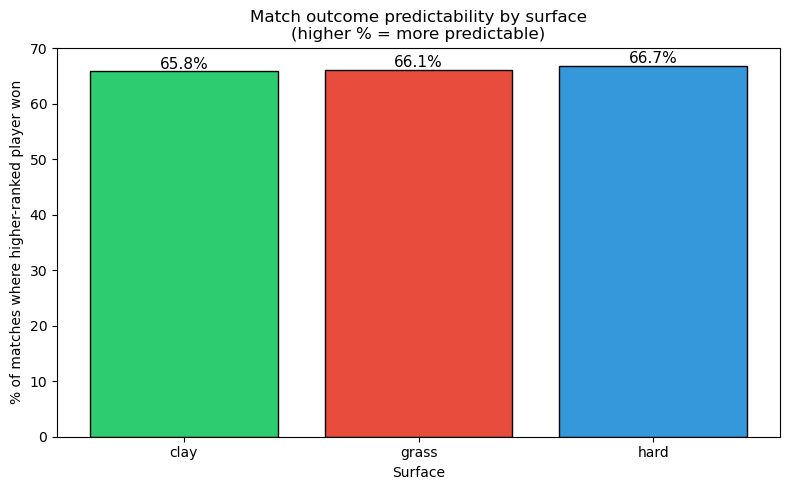

In [5]:
# Load processed data (if not already in memory from Section 1) and define outcome
df = pd.read_csv("data/02-processed/tennis_matches_processed_fullcols.csv")
df["higher_rank_won"] = df["winner_rank"] < df["loser_rank"]

# By surface (main three)
main_surfaces = ["hard", "clay", "grass"]
df_main = df[df["surface"].isin(main_surfaces)]
by_surface = df_main.groupby("surface").agg(
    n_matches=("higher_rank_won", "count"),
    pct_higher_rank_won=("higher_rank_won", "mean")
).assign(pct_higher_rank_won=lambda x: (x["pct_higher_rank_won"] * 100).round(2))
print(by_surface)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(by_surface.index, by_surface["pct_higher_rank_won"], color=["#2ecc71", "#e74c3c", "#3498db"], edgecolor="black")
ax.set_ylabel("% of matches where higher-ranked player won")
ax.set_xlabel("Surface")
ax.set_title("Match outcome predictability by surface\n(higher % = more predictable)")
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + 0.5, f"{h:.1f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

If the percentage of matches where the higher-ranked player wins differs across surfaces, that supports the idea that surface is relevant for prediction (e.g., one surface may have more upsets). Similar percentages across surfaces would suggest ranking alone might behave similarly regardless of surface, though we would still test adding surface in a model. This EDA sets up our modeling step: we will compare prediction accuracy with and without surface.

## Ethics

This section summarizes our consideration of ethical issues from the proposal (data collection, storage, analysis, modeling, and deployment).



Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.


Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.


[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)


### A. Data Collection
 - [] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?
 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
 
 > We have considered potential collection bias in the existing datasets. Professional tennis data may overrepresent top-ranked players and major tournaments while underrepresenting lower-tier events. We will document which tours and tournament levels are included and acknowledge any limitations in generalizability. We'll also examine whether certain surfaces or time periods are overrepresented in the data.


 
 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
 
 > The datasets contain player names, which are public figures in professional sports. However, we will minimize PII exposure by using player IDs or anonymized identifiers in our analysis wherever possible. We will not collect or display any personal information beyond what is publicly available in professional tennis records (names, rankings, match results).


 
 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?
> While our primary focus is on court surface and rankings, we will examine whether our model performs differently across various player demographics if such information is available. We'll document any potential biases in prediction accuracy and ensure our analysis doesn't perpetuate unfair advantages or disadvantages for particular player groups.




### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 
 > We will store all data files locally on password-protected devices and use secure cloud storage (e.g., Google Drive with restricted access) for team collaboration. Access will be limited to team members only. While the data is public, we will follow best practices for data management throughout the project lifecycle.
 
 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?


> We will retain the data only for the duration of the course project (approximately 10 weeks). After final grades are submitted and we no longer need the data for academic purposes, we will delete all local copies. The original datasets will remain available in their public repositories.


### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
 
 > We will consult with tennis subject matter experts (e.g., coaches, analysts) if possible to validate our assumptions about how surface types affect play. We'll also review tennis analytics literature to ensure we're not missing important contextual factors that might affect match outcomes.
 
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?


 > We will examine the data for potential biases including: temporal bias (whether recent matches are overrepresented), surface bias (whether certain surfaces have more data), and competitive level bias (whether Grand Slams vs. smaller tournaments are balanced). We'll document these biases and consider stratifying our analysis or using appropriate weighting techniques.
 
 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?


 > All visualizations and statistical summaries will accurately represent the underlying data without manipulation. We will include confidence intervals, report limitations, and avoid cherry-picking results. Any data exclusions or filtering decisions will be transparently documented and justified.
 
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?


 > Our analysis focuses on aggregate patterns and statistical relationships rather than individual player performance. While player names may appear in examples, we will not conduct individual-level analysis that could be used to unfairly characterize specific players' abilities.
 
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?


 > All analysis will be conducted in Jupyter notebooks with well-documented code, clear comments, and version control. We will maintain a reproducible workflow so that others can verify our methods and results. All data preprocessing steps, modeling decisions, and statistical tests will be explicitly documented.


### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?


 > Our model focuses on court surface type and ranking differences, which are legitimate competitive factors in tennis. We will ensure that we do not inadvertently use variables that serve as proxies for protected characteristics (e.g., nationality, age, gender) in discriminatory ways.
 
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?


 > We will test whether our model's prediction accuracy varies across different player groups (if demographic data is available) and report any disparities. Since this is an analytical project rather than a deployed system, we'll document but not necessarily resolve all fairness issues, while acknowledging them as limitations.
 
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?


 > We will use multiple evaluation metrics (e.g., accuracy, precision, recall, AUC-ROC) to assess model performance and will consider whether optimizing for one metric might have unintended consequences. We'll justify our choice of primary metric and report all relevant metrics.
 
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?


 > We will use interpretable modeling approaches and provide clear explanations of how court surface and ranking differences contribute to predictions. Feature importance analysis will help explain which factors most strongly influence match outcome predictions.
 
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?


 > Our final report will include a dedicated limitations section discussing: data coverage gaps, potential biases, model assumptions, generalizability constraints, and uncertainty in predictions. We will communicate these in clear, non-technical language where appropriate.




### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?


 > While we do not plan to deploy this model, we will include a statement in our report discouraging use of the model for gambling or other unintended purposes. We'll emphasize that this is an exploratory academic analysis and not a validated prediction system for real-world betting or decision-making.


## Team Expectations

* Our team will communicate through messages and we plan to meet in person at least once a week.
* Each team member will complete their assigned tasks by the agreed-upon deadlines and will communicate proactively if they encounter any obstacles or need additional time.
* If conflicts or misunderstandings come up, we will address them as a group and involve course staff if we are unable to resolve the issues on our own.
* We agree to be accountable to one another and follow the respected standards of academic integrity.
* All team members will come to meetings prepared, having completed their individual work and reviewed relevant materials beforehand.
* We will respect each other's time by starting and ending meetings on schedule and staying focused on agenda items.
* Team members will provide constructive feedback on each other's work in a respectful and supportive manner.
* If a team member cannot attend a scheduled meeting, they must notify the team at least 24 hours in advance and review meeting notes afterward.
* We will make decisions democratically, with all team members having equal input and voting rights on major project decisions.
* All work will be shared through our designated Google Drive folder with clear version control and file naming conventions.
* We commit to distributing work equitably across all team members and will reassess workload balance regularly to ensure fairness.
* Team members will respond to messages within 24 hours during weekdays to maintain efficient communication and project momentum.


## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/18  | 2 PM  | Finish data cleaning; start some early exploratory analysis to check data quality; review the EDA checkpoint instructions | Review and polish the data cleaning and early EDA; finalize the data checkpoint submission; assign tasks for the full EDA stage   |
| 2/25   | 2 PM  | Work individually on EDA tasks (including coding and writing interpretations); review feedback from the data checkpoint | Share progress on EDA work; discuss feedback on the data; decide how to implement any required changes |
| 3/4  | 2 PM  | Complete the main analysis; draft the results section; update the data section based on feedback| Finalize edits to the EDA section; plan and assign tasks for the project video |
| 3/11 | 2 PM | Draft the final project report; organize visualizations and write conclusions; begin an outline for the video presentation | Review the draft of the report; decide which visuals and explanations to use in the video; assign parts of the video to group members |
| 3/16 | 2 PM | Finish editing the final report; record and edit the project video; upload the video to the report as a public link | Do a final review of the report and video; confirm that the link is placed in the beginning of the report; prepare for the final submission before the March 18 deadline |
